<a href="https://colab.research.google.com/github/patelomniraj/Learning-about-Neural-Network/blob/main/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import math
import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [43]:
def f(x):
  return 4*x**2 - 8*x + 5


In [44]:
xs = np.arange(-5,5,.25)
y = f(xs)
y

array([145.  , 133.25, 122.  , 111.25, 101.  ,  91.25,  82.  ,  73.25,
        65.  ,  57.25,  50.  ,  43.25,  37.  ,  31.25,  26.  ,  21.25,
        17.  ,  13.25,  10.  ,   7.25,   5.  ,   3.25,   2.  ,   1.25,
         1.  ,   1.25,   2.  ,   3.25,   5.  ,   7.25,  10.  ,  13.25,
        17.  ,  21.25,  26.  ,  31.25,  37.  ,  43.25,  50.  ,  57.25])

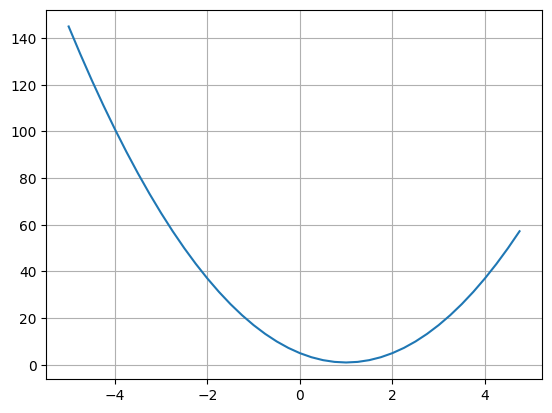

In [45]:
plt.plot(xs,y)
plt.grid()

In [49]:
h = 0.0001
x = 1
print("Before :",f(x))
print("After :",f(x+h))

print("Slope : (Gradient)  = ", (f(x+h)-f(x))/h)


Before : 1
After : 1.0000000399999998
Slope : (Gradient)  =  0.0003999999975690116


In [61]:
a = 2.0
b = 4.0
c = -2.0

h = 0.0001
d1 = a + b * c
print("Before D: ",d1)

c+=h
d2 = a + b * c

print("After D: ",d2)
print("Gradient :",(d2-d1)/h)

#dd/da = 1
#dd/db = -2.0
#dd/dc = 4



Before D:  -6.0
After D:  -5.9996
Gradient : 3.9999999999995595


In [24]:
class Value:
  def __init__( self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda : None
    self._prev  =  set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value( Data : {self.data} ) "

  def __add__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data + other.data,(self,other),'+')
    return out

  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data * other.data,(self,other),'*')
    return out

  def __rmul__(self,other): # if (2 * a) doesnt work, try (a * 2)
    return self * other

  def __neg__(self):
    return self*(-1)

  def __sub__(self,other):
    return self + (-other)

  def __truediv__(self,other):  # a/b = a * (b power -1)
    return self*(other**-1)

  def __radd__(self, other): # other + self
    return self + other


First Object Creation

In [ ]:
a = Value(2.0,label='A')
a

Addition operation

In [11]:
a = Value(4.5,label='a')
b = Value(3.0,label='b')
c = a + b
c

Value( Data : 7.5 ) 

Multiplication Operation

In [99]:
a = Value(4.5,label='a')
b = Value(3.0,label='b')
# ----- Weights ----
w1 = Value(2.60,label="w1")
w2 = Value(-8.45,label="w2")

c = ( 2.9 * a )

c

Value( Data : 13.049999999999999 ) 

Basic Neural Network

In [6]:
# Inputs
x = Value(1,label = 'X')
y = Value(3,label = 'Y')

#  Weights
w1 = Value(-8,label = 'W1')
w2 = Value(5,label = 'W2')

c = x*w1 + y*w2
c


Value( Data : 7 ) 

Plotting Code

In [7]:
from graphviz import Digraph

Building set of Nodes and Edges

In [12]:
def trace(root):
  nodes,edges = set(),set()
  def build(v):
    if v not in edges:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root)
  return nodes,edges

In [22]:
def draw_dot(root):
  dot = Digraph(format = 'svg', graph_attr = {'rankdir':'LR'} ) # LR -> Left to Right..

  nodes,edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node( name = uid,label = "{ %s | data %.3f | grad %.3f}" % (n.label, n.data,n.grad), shape = 'record' ) # Create a Rectangular Node
    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op , uid)
  for n1,n2 in edges:
    dot.edge(str(id(n1)),str(id(n2)) + n2._op)
  return dot


Simple Neural Network without Gradient

In [34]:
# Inputs
x = Value(1,label = 'X')
y = Value(3,label = 'Y')

#  Weights
w1 = Value(-8,label = 'W1')
w2 = Value(5,label = 'W2')

a = x*w1 ; a.label = 'A'
b =  y*w2 ; b.label = 'B'

c = a + b; c.label = 'C'


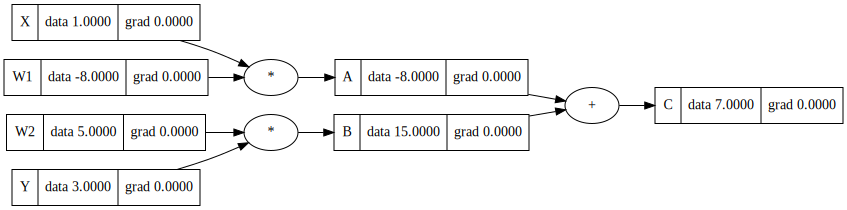

In [35]:
draw_dot(c)

Neural Network With Gradient

In [36]:
c.grad = 1
a.grad = 1 * c.grad
b.grad = 1 * c.grad

x.grad  = w1.data * a.grad
w1.grad = a.data * a.grad

y.grad  = w2.data * b.grad
w2.grad = b.data * b.grad

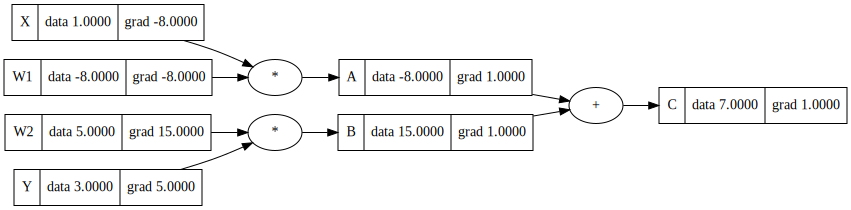

In [37]:
draw_dot(c)